# Simple LangGraph

## Build Simple Graph

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
model = ChatGroq(model='Gemma2-9b-It',groq_api_key=groq_api_key)
response = model.invoke([HumanMessage(content="Hi My name is Hanif, I'am Data Engineer")])

In [3]:
print(response.content)

Hello Hanif, it's nice to meet you! 

It's great to know you're a Data Engineer.  

What can I do for you today? Are you working on any interesting projects? Do you have any questions about data engineering or anything else?  I'm happy to chat and see if I can be helpful. 😊



**Nodes**

python function
state is first positional arguement
TypedDict can defined as schema to make sure the datat type. Each node can access the key, graph_state

Each node return a new value of state key graph_state

By defulat the new value returned by each node will override the prior state value

In [4]:
#define state
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info:str

In [5]:
# define node
def start_play(state:State):
    print('Start Play has been called')
    return {"graph_info":state['graph_info']+'I am planning to play'}

def badminton(state:State):
    print('Badminton Node has been called')
    return {"graph_info":state['graph_info']+'Badminton'}

def football(state:State):
    print('Football Node has been called')
    return {"graph_info":state['graph_info']+'Football'}

In [12]:
# define edge
import random
from typing import Literal

def random_play(state:State)->Literal['football','badminton']:
    graph_info = state['graph_info']

    if random.random() > 0.5:
        return 'football'
    else:
        return 'badminton'


Compiling Graph

StateGraph, Node and Edge have declared

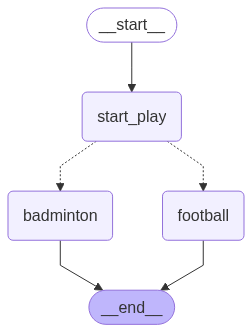

In [13]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
graph = StateGraph(State)
graph.add_node('start_play',start_play)
graph.add_node('football',football)
graph.add_node('badminton',badminton)

# schedule the flow of the graph

graph.add_edge(START, 'start_play')
graph.add_conditional_edges('start_play',random_play)
graph.add_edge('football',END)
graph.add_edge('badminton',END)

# compile the graph

graph_builder = graph.compile()

# View

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [15]:
graph_builder.invoke({'graph_info':'Hey my name is Hanif' })

Start Play has been called
Football Node has been called


{'graph_info': 'Hey my name is HanifI am planning to playFootball'}

## Simple ChatBot LangGraph 

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

## redducers add annotation in our message
from typing import Annotated
from langgraph.graph.message import add_messages

In [19]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [24]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

In [21]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
model = ChatGroq(model='Gemma2-9b-It',groq_api_key=groq_api_key)
response = model.invoke([HumanMessage(content="Hi My name is Hanif, I'am Data Engineer")])

In [25]:
print(response.content)

Hello Hanif, it's nice to meet you!  

Being a Data Engineer is a fascinating field. What kind of projects are you working on these days? 

I'm always eager to learn more about the work that people do in different areas.



In [26]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", api_key=GOOGLE_API_KEY)
result = llm.invoke("Hi My name is Hanif, I'am Data Engineer")
print(result.content)

It's nice to meet you, Hanif!  It's great to hear you're a Data Engineer.


In [28]:
def graphbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

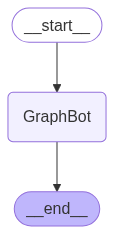

In [29]:
graph = StateGraph(State)

graph.add_node('GraphBot', graphbot)

graph.add_edge(START, 'GraphBot')
graph.add_edge('GraphBot', END)

graph_compiled = graph.compile()


display(Image(graph_compiled.get_graph().draw_mermaid_png()))


In [36]:
response = graph_compiled.invoke({'messages':'Hi my name is Hanif, I am Data Engineer '})
print(response)

{'messages': [HumanMessage(content='Hi my name is Hanif, I am Data Engineer ', additional_kwargs={}, response_metadata={}, id='8792d96b-6e57-4bed-bc7f-9701ccae6bb7'), AIMessage(content="Nice to meet you, Hanif!  It's good to know you're a Data Engineer.  Is there anything I can help you with today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--6f72a380-c21f-49db-8d72-126ca28e73a9-0', usage_metadata={'input_tokens': 12, 'output_tokens': 34, 'total_tokens': 46, 'input_token_details': {'cache_read': 0}})]}


In [41]:
for event in graph_compiled.stream({"messages":"Hi my name is Hanif , I'm Data Engineer"},stream_mode="updates"):
    print(event)

{'GraphBot': {'messages': [AIMessage(content="It's nice to meet you, Hanif!  I'm glad to hear you're a Data Engineer.  Is there anything I can help you with today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--c17ffb58-32c4-4d46-8ff2-a98b8756b931-0', usage_metadata={'input_tokens': 12, 'output_tokens': 37, 'total_tokens': 49, 'input_token_details': {'cache_read': 0}})]}}
